## Importing Libraries

In [19]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import (
    LogisticRegressionModel,
    DecisionTreeClassificationModel,
    RandomForestClassificationModel,
    LinearSVCModel
)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)


os.makedirs("Task5_Output", exist_ok=True)

In [2]:
spark = SparkSession.builder \
    .appName("Task5_Model_Evaluation") \
    .config("spark.driver.memory","8g") \
    .config("spark.sql.shuffle.partitions","16") \
    .getOrCreate()

In [4]:
from google.colab import files

uploaded = files.upload()

Saving Saved_Models.zip to Saved_Models.zip


## Extracting ZIP File

In [5]:
import zipfile
import os

zip_path = "Saved_Models.zip"

extract_path = "Saved_Models"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(" ZIP extracted successfully.")

 ZIP extracted successfully.


## Checking Folder Structure

In [6]:
for root, dirs, files in os.walk("Saved_Models"):
    print(root)
    for file in files:
        print("   ", file)

Saved_Models
    Model_Metrics.csv
Saved_Models/Logistic_Regression
Saved_Models/Logistic_Regression/metadata
    .part-00000-8348255b-8eca-4083-9aee-9cc791e949e3-c000.txt.crc
    _SUCCESS
    part-00000-8348255b-8eca-4083-9aee-9cc791e949e3-c000.txt
    ._SUCCESS.crc
Saved_Models/Logistic_Regression/data
    part-00000-03c4ba62-5fee-42a0-8085-b1a4bc06b3e5-c000.snappy.parquet
    _SUCCESS
    .part-00000-03c4ba62-5fee-42a0-8085-b1a4bc06b3e5-c000.snappy.parquet.crc
    ._SUCCESS.crc
Saved_Models/SVM_Predictions
    .part-00002-eb849a0e-97c4-4668-94c5-09ab706883ba-c000.snappy.parquet.crc
    part-00001-eb849a0e-97c4-4668-94c5-09ab706883ba-c000.snappy.parquet
    part-00000-eb849a0e-97c4-4668-94c5-09ab706883ba-c000.snappy.parquet
    .part-00001-eb849a0e-97c4-4668-94c5-09ab706883ba-c000.snappy.parquet.crc
    .part-00000-eb849a0e-97c4-4668-94c5-09ab706883ba-c000.snappy.parquet.crc
    _SUCCESS
    ._SUCCESS.crc
    part-00002-eb849a0e-97c4-4668-94c5-09ab706883ba-c000.snappy.parquet
Saved_M

## Loading All Models

In [7]:
from pyspark.ml.classification import (
    LogisticRegressionModel,
    DecisionTreeClassificationModel,
    RandomForestClassificationModel,
    LinearSVCModel
)

lr_model = LogisticRegressionModel.load(
    "Saved_Models/Logistic_Regression"
)

dt_model = DecisionTreeClassificationModel.load(
    "Saved_Models/Decision_Tree"
)

rf_model = RandomForestClassificationModel.load(
    "Saved_Models/Random_Forest"
)

svm_model = LinearSVCModel.load(
    "Saved_Models/Linear_SVM"
)

print(" All models loaded successfully.")

 All models loaded successfully.


## Loading Prediction Files

In [8]:
pred_lr = spark.read.parquet(
    "Saved_Models/LR_Predictions"
)

pred_dt = spark.read.parquet(
    "Saved_Models/DT_Predictions"
)

pred_rf = spark.read.parquet(
    "Saved_Models/RF_Predictions"
)

pred_svm = spark.read.parquet(
    "Saved_Models/SVM_Predictions"
)

print(" All prediction files loaded successfully.")

 All prediction files loaded successfully.


## Loading Metrics CSV

In [9]:
metrics = pd.read_csv("Saved_Models/Model_Metrics.csv")

metrics

,Model,Training Time (s),Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,60.72,0.5387,0.5367,0.5387,0.4358,0.5407
1,Decision Tree,54.42,0.5339,0.6640,0.5339,0.3726,0.5389
2,Random Forest,296.04,0.5380,0.7011,0.5380,0.3825,0.5586
3,Linear SVM,69.91,0.5334,0.5266,0.5334,0.3712,0.5392


In [12]:
accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

In [13]:
import builtins

evaluation_results = []

os.makedirs("Task5_Output", exist_ok=True)

def evaluate_saved_prediction(model_name, prediction_df):

    accuracy = accuracy_eval.evaluate(prediction_df)

    precision = precision_eval.evaluate(prediction_df)

    recall = recall_eval.evaluate(prediction_df)

    f1 = f1_eval.evaluate(prediction_df)

    try:
        auc = auc_eval.evaluate(prediction_df)
    except:
        auc = None

    pdf = prediction_df.select(
        "label",
        "prediction"
    ).toPandas()

    y_true = pdf["label"]

    y_pred = pdf["prediction"]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    fig, ax = plt.subplots(figsize=(6,6))

    disp.plot(
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    plt.title(f"{model_name} Confusion Matrix")

    plt.savefig(
        f"Task5_Output/{model_name}_ConfusionMatrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("="*60)
    print(model_name)
    print("="*60)

    print("Accuracy :",builtins.round(accuracy,4))
    print("Precision :",builtins.round(precision,4))
    print("Recall :",builtins.round(recall,4))
    print("F1 Score :",builtins.round(f1,4))

    if auc is not None:
        print("AUC :",builtins.round(auc,4))
    else:
        print("AUC : N/A")

    print("\nClassification Report\n")

    print(classification_report(
        y_true,
        y_pred
    ))

    evaluation_results.append({

        "Model":model_name,

        "Accuracy":builtins.round(accuracy,4),

        "Precision":builtins.round(precision,4),

        "Recall":builtins.round(recall,4),

        "F1 Score":builtins.round(f1,4),

        "AUC":None if auc is None else builtins.round(auc,4)

    })

## Logistic Regression Confusion Matrix

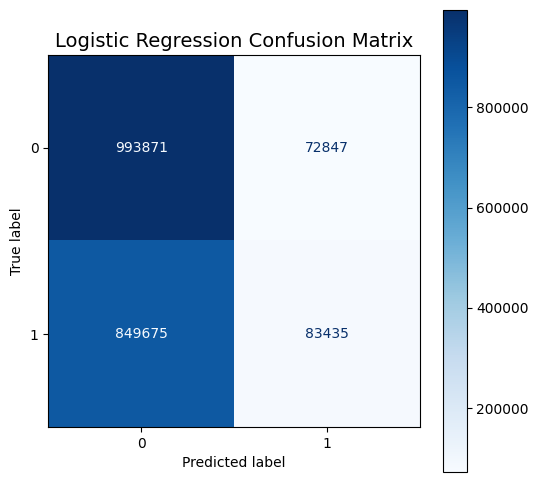

In [15]:
pdf = pred_lr.select("label", "prediction").toPandas()

cm = confusion_matrix(pdf["label"], pdf["prediction"])

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="Blues",
    values_format='d',
    colorbar=True,
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix", fontsize=14)
plt.grid(False)

plt.savefig(
    "Task5_Output/Logistic_Regression_CM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Decision Tree Confusion Matrix

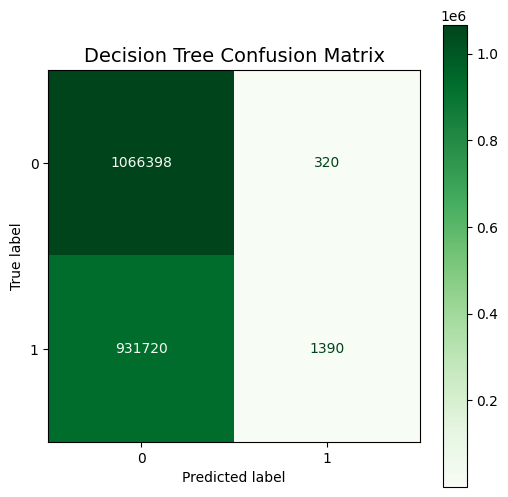

In [16]:
pdf = pred_dt.select("label", "prediction").toPandas()

cm = confusion_matrix(pdf["label"], pdf["prediction"])

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="Greens",
    values_format='d',
    colorbar=True,
    ax=ax
)

plt.title("Decision Tree Confusion Matrix", fontsize=14)
plt.grid(False)

plt.savefig(
    "Task5_Output/Decision_Tree_CM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Random Forest Confusion Matrix

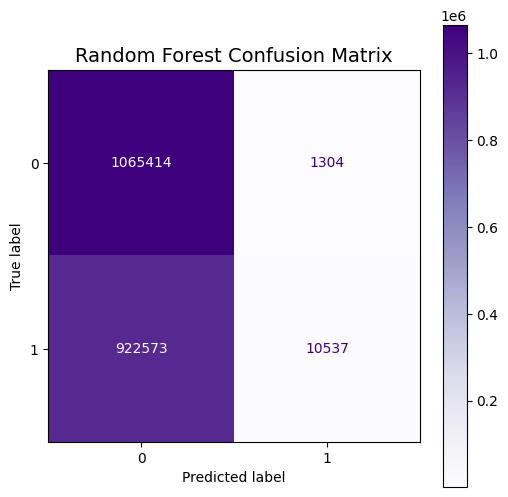

In [17]:
pdf = pred_rf.select("label", "prediction").toPandas()

cm = confusion_matrix(pdf["label"], pdf["prediction"])

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="Purples",
    values_format='d',
    colorbar=True,
    ax=ax
)

plt.title("Random Forest Confusion Matrix", fontsize=14)
plt.grid(False)

plt.savefig(
    "Task5_Output/Random_Forest_CM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Linear SVM Confusion Matrix

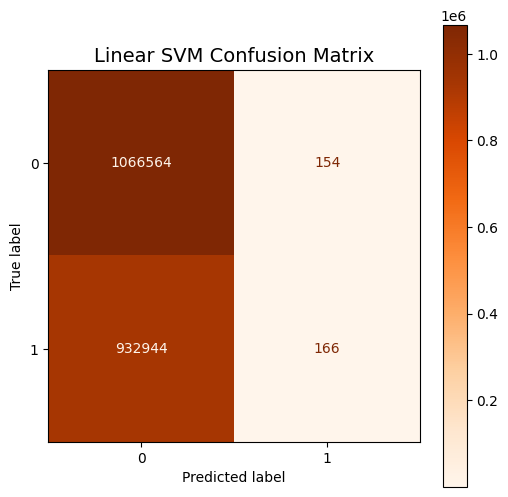

In [18]:
pdf = pred_svm.select("label", "prediction").toPandas()

cm = confusion_matrix(pdf["label"], pdf["prediction"])

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(
    cmap="Oranges",
    values_format='d',
    colorbar=True,
    ax=ax
)

plt.title("Linear SVM Confusion Matrix", fontsize=14)
plt.grid(False)

plt.savefig(
    "Task5_Output/Linear_SVM_CM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Functions to Extract Scores

In [20]:
def prepare_scores(prediction_df, model_type="probability"):

    pdf = prediction_df.toPandas()

    y_true = pdf["label"]

    if model_type == "probability":
        scores = pdf["probability"].apply(lambda x: float(x[1]))

    else:
        scores = pdf["rawPrediction"].apply(lambda x: float(x[1]))

    return y_true, scores

## ROC Curves

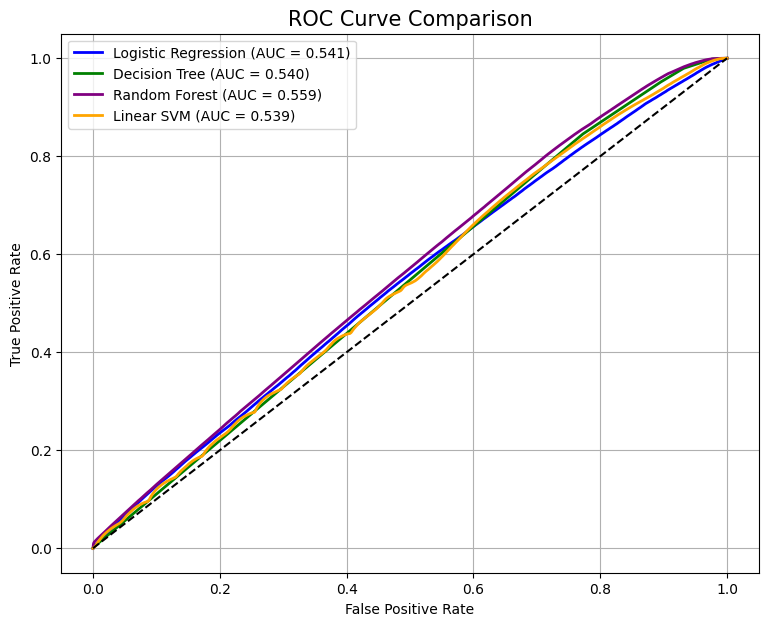

In [21]:
plt.figure(figsize=(9,7))

# Logistic Regression
y_true, scores = prepare_scores(pred_lr)

fpr, tpr, _ = roc_curve(y_true, scores)

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"Logistic Regression (AUC = {auc(fpr,tpr):.3f})"
)

# Decision Tree
y_true, scores = prepare_scores(pred_dt)

fpr, tpr, _ = roc_curve(y_true, scores)

plt.plot(
    fpr,
    tpr,
    color="green",
    linewidth=2,
    label=f"Decision Tree (AUC = {auc(fpr,tpr):.3f})"
)

# Random Forest
y_true, scores = prepare_scores(pred_rf)

fpr, tpr, _ = roc_curve(y_true, scores)

plt.plot(
    fpr,
    tpr,
    color="purple",
    linewidth=2,
    label=f"Random Forest (AUC = {auc(fpr,tpr):.3f})"
)

# Linear SVM
y_true, scores = prepare_scores(pred_svm,"raw")

fpr, tpr, _ = roc_curve(y_true, scores)

plt.plot(
    fpr,
    tpr,
    color="orange",
    linewidth=2,
    label=f"Linear SVM (AUC = {auc(fpr,tpr):.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    'k--'
)

plt.title("ROC Curve Comparison",fontsize=15)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.savefig(
    "Task5_Output/ROC_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Precision-Recall Curves

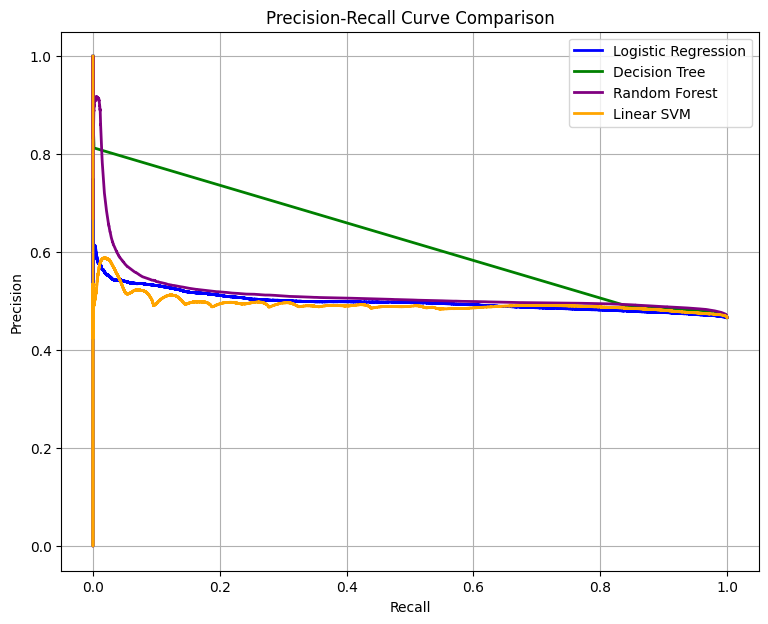

In [22]:
plt.figure(figsize=(9,7))

# Logistic Regression
y_true, scores = prepare_scores(pred_lr)

precision, recall, _ = precision_recall_curve(y_true,scores)

plt.plot(
    recall,
    precision,
    color="blue",
    linewidth=2,
    label="Logistic Regression"
)

# Decision Tree
y_true, scores = prepare_scores(pred_dt)

precision, recall, _ = precision_recall_curve(y_true,scores)

plt.plot(
    recall,
    precision,
    color="green",
    linewidth=2,
    label="Decision Tree"
)

# Random Forest
y_true, scores = prepare_scores(pred_rf)

precision, recall, _ = precision_recall_curve(y_true,scores)

plt.plot(
    recall,
    precision,
    color="purple",
    linewidth=2,
    label="Random Forest"
)

# Linear SVM
y_true, scores = prepare_scores(pred_svm,"raw")

precision, recall, _ = precision_recall_curve(y_true,scores)

plt.plot(
    recall,
    precision,
    color="orange",
    linewidth=2,
    label="Linear SVM"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve Comparison")

plt.legend()

plt.grid(True)

plt.savefig(
    "Task5_Output/Precision_Recall_Curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## AUC Comparison Table

In [23]:
from sklearn.metrics import roc_auc_score

auc_results = []

for name, pred, typ in [

    ("Logistic Regression",pred_lr,"probability"),

    ("Decision Tree",pred_dt,"probability"),

    ("Random Forest",pred_rf,"probability"),

    ("Linear SVM",pred_svm,"raw")

]:

    y_true, scores = prepare_scores(pred,typ)

    auc_results.append({

        "Model":name,

        "AUC":roc_auc_score(y_true,scores)

    })

auc_df = pd.DataFrame(auc_results)

auc_df

,Model,AUC
0,Logistic Regression,0.540692
1,Decision Tree,0.540163
2,Random Forest,0.558601
3,Linear SVM,0.539229


In [26]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *

spark = SparkSession.builder \
    .appName("Task5_Perturbation") \
    .getOrCreate()

df = spark.read.parquet("nifty_10m_fixed.parquet")

In [27]:
df = df.withColumn(
    "label",
    when(col("close") > col("open"), 1).otherwise(0)
)

## Rebuilding Feature Pipeline

In [28]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

numerical = [
    "open",
    "high",
    "low",
    "iv",
    "volume",
    "oi",
    "strike_price",
    "spot"
]

categorical = [
    "expiry_type",
    "strike_type",
    "option_type"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c+"_index",
        handleInvalid="keep"
    )
    for c in categorical
]

encoder = OneHotEncoder(
    inputCols=[c+"_index" for c in categorical],
    outputCols=[c+"_vec" for c in categorical]
)

assembler = VectorAssembler(
    inputCols=numerical,
    outputCol="num_features"
)

scaler = StandardScaler(
    inputCol="num_features",
    outputCol="scaled_num"
)

assembler2 = VectorAssembler(
    inputCols=[
        "scaled_num",
        "expiry_type_vec",
        "strike_type_vec",
        "option_type_vec"
    ],
    outputCol="features"
)

pipeline = Pipeline(
    stages=indexers + [
        encoder,
        assembler,
        scaler,
        assembler2
    ]
)

pipeline_model = pipeline.fit(df)

data = pipeline_model.transform(df).select(
    "features",
    "label"
)

In [30]:
sample = data.sample(
    fraction=0.005,
    seed=42
)

In [31]:
from pyspark.ml.classification import (
    LogisticRegressionModel,
    DecisionTreeClassificationModel,
    RandomForestClassificationModel,
    LinearSVCModel
)

lr_model = LogisticRegressionModel.load("Saved_Models/Logistic_Regression")
dt_model = DecisionTreeClassificationModel.load("Saved_Models/Decision_Tree")
rf_model = RandomForestClassificationModel.load("Saved_Models/Random_Forest")
svm_model = LinearSVCModel.load("Saved_Models/Linear_SVM")

## Perturb Features

In [32]:
from pyspark.sql.functions import udf
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np

def perturb(v):

    arr = np.array(v)

    noise = np.random.normal(
        0,
        0.05,
        len(arr)
    )

    return Vectors.dense(arr + noise)

perturb_udf = udf(
    perturb,
    VectorUDT()
)

perturbed = sample.withColumn(
    "features",
    perturb_udf("features")
)

## Function for Stability

In [33]:
def stability(model, original, perturbed):

    p1 = model.transform(original)

    p2 = model.transform(perturbed)

    pred1 = p1.select("prediction").toPandas()

    pred2 = p2.select("prediction").toPandas()

    stability = (
        pred1["prediction"] ==
        pred2["prediction"]
    ).mean()

    return stability * 100

## Stability Results

In [35]:
results = []

models = [

    ("Logistic Regression", lr_model),

    ("Decision Tree", dt_model),

    ("Random Forest", rf_model),

    ("Linear SVM", svm_model)

]

for name, model in models:

    score = stability(

        model,

        sample,

        perturbed

    )

    print(name, ":", builtins.round(score,2), "%")

    results.append({

        "Model": name,

        "Prediction Stability (%)": builtins.round(score,2)

    })

stability_df = pd.DataFrame(results)

stability_df

Logistic Regression : 94.69 %
Decision Tree : 98.05 %
Random Forest : 95.29 %
Linear SVM : 100.0 %


,Model,Prediction Stability (%)
0,Logistic Regression,94.69
1,Decision Tree,98.05
2,Random Forest,95.29
3,Linear SVM,100.00


## Plot Stability

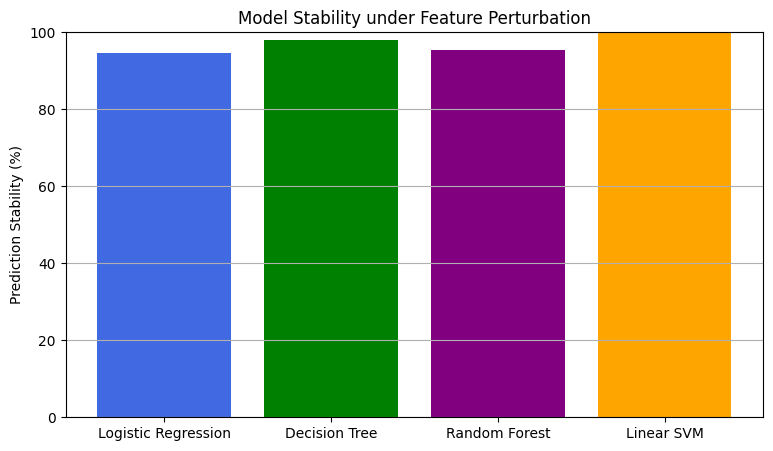

In [36]:
plt.figure(figsize=(9,5))

plt.bar(

    stability_df["Model"],

    stability_df["Prediction Stability (%)"],

    color=[
        "royalblue",
        "green",
        "purple",
        "orange"
    ]

)

plt.ylabel("Prediction Stability (%)")

plt.title("Model Stability under Feature Perturbation")

plt.ylim(0,100)

plt.grid(axis="y")

plt.savefig(
    "Task5_Output/Perturbation_Stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
from sklearn.model_selection import train_test_split
import numpy as np

# Use the processed Spark data
sample = data.limit(1000)

sample_pd = sample.toPandas()

X = np.vstack(
    sample_pd["features"].apply(lambda x: x.toArray())
)

y = sample_pd["label"]

In [51]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [52]:
!pip install lime

In [53]:
from lime.lime_tabular import LimeTabularExplainer

In [54]:
feature_names = [f"Feature_{i}" for i in range(X.shape[1])]

## Creating Explainer

In [55]:
explainer = LimeTabularExplainer(

    training_data=X_train,

    feature_names=feature_names,

    class_names=["Down","Up"],

    mode="classification"
)

## Explain One Prediction

In [46]:
explanation = explainer.explain_instance(

    X[0],

    predict_fn,

    num_features=8
)

## Displaying Explanation

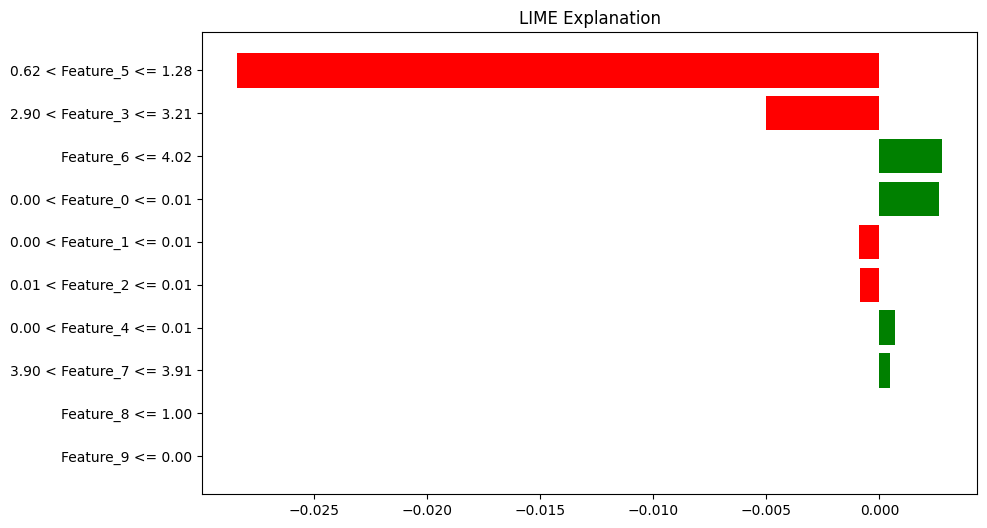

In [59]:
fig = exp.as_pyplot_figure()

fig.set_size_inches(10,6)

plt.title("LIME Explanation")

plt.savefig(

    "Task5_Output/LIME.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()